## Necessary code for loading Base model

### GPT Architecture

In [1]:
import torch
from torch import nn

In [2]:
class MultiHeadedAttention(nn.Module):
  def __init__(self, d_in, d_out, bias, dropout, num_heads, context_window):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out//num_heads
    self.w_q = nn.Linear(d_in, d_out, bias = bias)
    self.w_k = nn.Linear(d_in, d_out, bias = bias)
    self.w_v = nn.Linear(d_in, d_out, bias = bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask",
                         torch.triu(torch.ones(context_window, context_window),
                         diagonal = 1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)
    q = q.view(b, num_tokens, self.num_heads, self.head_dim)
    k = k.view(b, num_tokens, self.num_heads, self.head_dim)
    v = v.view(b, num_tokens, self.num_heads, self.head_dim)
    q = q.transpose(1, 2)
    k = k.transpose(1, 2)
    v = v.transpose(1, 2)
    #qkv = b, num_heads, num_tokens, head_dim
    product = q @ k.transpose(2,3)
    #(b, num_heads, num_tokens, head_dim) x (b, num_heads, head_dim, num_tokens)
    #=> product = (b, num_heads, num_tokens, num_tokens)
    mask = self.mask.bool()[:num_tokens, :num_tokens]
    product.masked_fill_(mask, -torch.inf)

    attn_score = torch.softmax(product / (k.shape[-1]**0.5)  , dim =  -1)
    attn_score = self.dropout(attn_score)

    context_vector = (attn_score @ v).transpose(1,2)
    #(b, num_heads, num_tokens, num_tokens) x (b, num_heads, num_tokens, head_dim)
    # => context vector = (b, num_heads, num_tokens, head_dim)
    # => context vector = (b, num_tokens, num_heads, head_dim)
    context_vector = context_vector.contiguous().view(b, num_tokens, self.d_out)
    context_vector = self.out_proj(context_vector)
    return context_vector

In [3]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
  #scale and shift are learnable params the model can change if it imporves performance

  def forward(self, x):
    mean = x.mean(dim = -1, keepdim = True)
    var = x.var(dim = -1, keepdim = True, unbiased = False)
    #unbiased = false => not using bessel correction of (n-1) instead of n
    z = (x - mean) / ((var+1e-5)**0.5)
    return self.scale*z + self.shift



class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))



class FeedForward(nn.Module):
  def __init__(self, x):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(x["emb_dim"], 4 * x["emb_dim"]),
        GELU(),
        nn.Linear(4 * x["emb_dim"], x["emb_dim"]))

  def forward(self, x):
    return self.layers(x)

In [4]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    #cfg is the configuration dictionary
    super().__init__()
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.attn = MultiHeadedAttention(d_in = cfg["emb_dim"], d_out = cfg["emb_dim"], bias = cfg["bias"],
                                           dropout = cfg["drop_rate"], num_heads = cfg["n_heads"],
                                           context_window = cfg["context_window"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.ff = FeedForward(cfg)

  def forward(self, x):
    residual = x
    x = self.norm1(x)
    x = self.attn(x)
    x = self.dropout(x)
    x = residual + x
    residual = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.dropout(x)
    return residual + x

In [5]:
class GeePeeTee(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embed = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.position_embed = nn.Embedding(cfg["context_window"], cfg["emb_dim"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.transformer = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.output = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = cfg["bias"])

  def forward(self, x):
    batch_size, seq_len = x.shape
    token_embed = self.token_embed(x)
    position_embed = self.position_embed(torch.arange(seq_len, device=x.device))
    y = token_embed + position_embed
    y = self.dropout(y)
    y = self.transformer(y)
    y = self.final_norm(y)
    logits = self.output(y)
    return logits

### Loading pretrained weights from openai

In [6]:
import urllib.request
url = (
 "https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch05/"
 "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="355M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 140kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.76MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 138kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [05:07<00:00, 4.61MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 4.39MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.40MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.59MiB/s]


In [7]:
NEW_CONFIG = {
 "vocab_size": 50257, # Vocabulary size (BPE tokenizer)
 "context_window": 1024, # Context length
 "emb_dim": 1024, # Embedding dimension
 "n_heads": 16, # Number of attention heads
 "n_layers": 24, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "bias": True #generally not used
}

In [8]:
gpt = GeePeeTee(NEW_CONFIG)
gpt.eval()

GeePeeTee(
  (token_embed): Embedding(50257, 1024)
  (position_embed): Embedding(1024, 1024)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadedAttention(
        (w_q): Linear(in_features=1024, out_features=1024, bias=True)
        (w_k): Linear(in_features=1024, out_features=1024, bias=True)
        (w_v): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (

In [9]:
def assign(left, right):
 if left.shape != right.shape:
  raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
 return torch.nn.Parameter(torch.tensor(right))


import numpy as np
def load_weights_into_gpt(gpt, params):
  gpt.position_embed.weight = assign(gpt.position_embed.weight, params['wpe'])
  gpt.token_embed.weight = assign(gpt.token_embed.weight, params['wte'])

  for b in range(len(params["blocks"])):

    Q_w, K_w, V_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
    gpt.transformer[b].attn.w_q.weight = assign(gpt.transformer[b].attn.w_q.weight, Q_w.T)
    gpt.transformer[b].attn.w_k.weight = assign(gpt.transformer[b].attn.w_k.weight, K_w.T)
    gpt.transformer[b].attn.w_v.weight = assign(gpt.transformer[b].attn.w_v.weight, V_w.T)

    Q_b, K_b, V_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
    gpt.transformer[b].attn.w_q.bias = assign(gpt.transformer[b].attn.w_q.bias, Q_b)
    gpt.transformer[b].attn.w_k.bias = assign(gpt.transformer[b].attn.w_k.bias, K_b)
    gpt.transformer[b].attn.w_v.bias = assign(gpt.transformer[b].attn.w_v.bias, V_b)

    gpt.transformer[b].attn.out_proj.weight = assign(gpt.transformer[b].attn.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.transformer[b].attn.out_proj.bias = assign(gpt.transformer[b].attn.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
    gpt.transformer[b].ff.layers[0].weight = assign(gpt.transformer[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.transformer[b].ff.layers[0].bias = assign(gpt.transformer[b].ff.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.transformer[b].ff.layers[2].weight = assign(gpt.transformer[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.transformer[b].ff.layers[2].bias = assign(gpt.transformer[b].ff.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

    gpt.transformer[b].norm1.scale = assign(gpt.transformer[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.transformer[b].norm1.shift = assign(gpt.transformer[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
    gpt.transformer[b].norm2.scale = assign(gpt.transformer[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.transformer[b].norm2.shift = assign(gpt.transformer[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

  gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
  gpt.output.weight = assign(gpt.output.weight, params["wte"])

In [10]:
def text2token(text, tokenizer):
  encoded = tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  return torch.tensor(encoded).unsqueeze(0)

def token2text(tokens, tokenizer):
  tokens = tokens.squeeze(0)
  return tokenizer.decode(tokens.tolist())


def generate(model, input, max_new_tokens, context_window,
             temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    input = input.to(model.parameters().__next__().device)
    cropped = input[:, -context_window:]  #only uses last len(context_window) tokens
    with torch.no_grad():
      logits = model(cropped)
    logits = logits[:, -1, :]
    #input/logits shape = (batch, tokens)
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val.to(logits.device), torch.tensor(float('-inf')).to(logits.device), logits)

    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      next = torch.multinomial(probs, num_samples=1)
    else:
      next = torch.argmax(logits, dim=-1, keepdim=True)

    next = next.to(input.device) #device compatibility

    if next == eos_id:
      break
    input = torch.cat((input, next), dim=1)
  return input

In [11]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
load_weights_into_gpt(gpt, params)
device = "cuda" if torch.cuda.is_available() else "cpu"
gpt.to(device)

token_ids = generate(model = gpt,
                     input = text2token("Convert 1 kilometer to meter", tokenizer).to(device),
                     max_new_tokens = 40, context_window = NEW_CONFIG["context_window"],
                     temperature = 1.5, top_k = 20)
print("Output text:\n", token2text(token_ids, tokenizer))

Output text:
 Convert 1 kilometer to meter.

Convert 1 foot to inches.

Convert 8 square inches or cubic meters.

Convert 10,000 grams or cubic feet of air.<|endoftext|>As if that didn


# Finetuning the model

## Loading dataset

In [12]:
import json
import os
import urllib
def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
      text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)
  else:
    with open(file_path, "r", encoding="utf-8") as file:
      text_data = file.read()

  with open(file_path, "r") as file:
      data = json.load(file)
  return data

file_path = "instruction-data.json"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json")
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [13]:
print("Example entry:\n", data[1])
print("Example entry:\n", data[2])

Example entry:
 {'instruction': 'Edit the following sentence for grammar.', 'input': 'He go to the park every day.', 'output': 'He goes to the park every day.'}
Example entry:
 {'instruction': 'Convert 45 kilometers to meters.', 'input': '', 'output': '45 kilometers is 45000 meters.'}


In [14]:
def format_input(data):
  instruction_text = (
 f"Below is an instruction that describes a task. Write a response that appropriately completes the request."
 f"\n\n### Instruction:\n{data['instruction']}")
  input_text = (f"\n\n### Input:\n{data['input']}" if data["input"] else "")
  return instruction_text + input_text

In [15]:
model_input = format_input(data[1])
desired_response = f"\n\n### Response:\n{data[1]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Edit the following sentence for grammar.

### Input:
He go to the park every day.

### Response:
He goes to the park every day.


Split dataset

In [16]:
train_split = int(len(data)*0.85)
valid_split = int(len(data)*0.05)
test_split = int(len(data)*0.1)

train_data = data[:train_split]
valid_data = data[train_split:train_split+valid_split]
test_data = data[train_split + valid_split:]

print("Training set length:", len(train_data))
print("Validation set length:", len(valid_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


In [17]:
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.encoded = []
    for entry in data:
      input = format_input(entry)
      response = f"\n\n### Response:\n{entry['output']}"
      full = input + response
      self.encoded.append(tokenizer.encode(full))

  def __getitem__(self, index):
    return self.encoded[index]

  def __len__(self):
    return len(self.data)

In [18]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


Implementing a padding process

In [19]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (inputs_1,inputs_2,inputs_3)

In [20]:
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]
    padded = (new_item + [pad_token_id] *(batch_max_length - len(new_item)))
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])
    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]
    inputs_lst.append(inputs)
    targets_lst.append(targets)
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

In [21]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [22]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

train_dataset = InstructionDataset(train_data, tokenizer)
valid_dataset = InstructionDataset(valid_data, tokenizer)
test_dataset = InstructionDataset(test_data, tokenizer)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size,
                              collate_fn=custom_collate_fn, shuffle = True, drop_last = True, num_workers=num_workers)
valid_dataloader = DataLoader(dataset=valid_dataset, batch_size=batch_size,
                              collate_fn=custom_collate_fn, shuffle = False, drop_last = False, num_workers=num_workers)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size,
                              collate_fn=custom_collate_fn, shuffle = False, drop_last = False, num_workers=num_workers)

In [23]:
def loss_batch(input, target, model, device):
  input = input.to(device)
  target = target.to(device)
  # The model outputs logits for each token in the sequence
  output = model(input)
  # Reshape output and target for cross_entropy
  output = output.view(-1, output.size(-1))
  target = target.view(-1)
  loss = torch.nn.functional.cross_entropy(output, target)
  return loss

def loss_dataloader(dataloader, model, device, num_batches):
  total_loss = 0
  if len(dataloader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(dataloader)
  else:
    num_batches = min(len(dataloader), num_batches)

  for i, (input, target) in enumerate(dataloader):
    if i < num_batches:
      loss = loss_batch(input, target, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss/num_batches

In [24]:
def trainLLM(model, train_loader, val_loader, optimizer, device,
             epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_list, valid_loss_list, tokens_seen_list = [], [], []
  tokens_seen, global_step = 0 , -1
  for epoch in range(epochs):
    #Training
    model.train()
    for input, target in train_dataloader: #will run no. of batches times
      optimizer.zero_grad()
      loss = loss_batch(input, target, model, device)
      loss.backward()
      optimizer.step()
      tokens_seen += input.numel()
      global_step += 1

    #Evaluation Step (optional)
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_dataloader, test_dataloader, device, eval_iter)
        train_loss_list.append(train_loss)
        valid_loss_list.append(val_loss)
        tokens_seen_list.append(tokens_seen)
        print(f"Epoch {epoch+1} (Step {global_step:06d}): | Train loss: {train_loss:.3f} | Val loss: {val_loss:.3f}")

      generate_sample(model, tokenizer, device, start_context)
  return train_loss_list, valid_loss_list, tokens_seen_list


def evaluate_model(model, train_dataloader, test_dataloader, device, eval_iter):
  model.eval()
  train_loss = loss_dataloader(train_dataloader, model, device, eval_iter)
  test_loss = loss_dataloader(test_dataloader, model, device, eval_iter)
  model.train()
  return train_loss, test_loss

def generate_sample(model, tokenizer, device, start_context):
  model.eval()
  context_window = model.position_embed.weight.shape[0]
  encoded = text2token(start_context, tokenizer).to(device)
  with torch.no_grad():
    id = generate(model, encoded, 50, context_window)
  decoded = token2text(id, tokenizer)
  print(decoded.replace("\n"," "))
  model.train()

In [25]:
gpt.to(device)
optimizer = torch.optim.AdamW(gpt.parameters(),lr=0.00005, weight_decay=0.1)
epochs = 1
train_loss, val_loss, tokens_seen = trainLLM(gpt, train_dataloader, train_dataloader, optimizer, device,
                                                 epochs=epochs, eval_freq=5, eval_iter=5,
                                                 start_context= format_input(valid_data[0]), tokenizer=tokenizer)

Epoch 1 (Step 000000): | Train loss: 2.510 | Val loss: 2.575
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Rewrite the sentence using a simile.  ### Input: The car is very fast.  ### Response: The car is very fast.  ### Instruction: Write a response that appropriately completes the request.  ### Input: The car is very fast.  ### Response: The car is very fast
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Rewrite the sentence using a simile.  ### Input: The car is very fast.  ### Response: The car is very fast.  ### Response: The car is very fast.  ### Response: The car is very fast. ### Response: The car is very fast. ### Response
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Rewrite the sentence using a simile.  ### Input: The car is very fast.  ### Respo

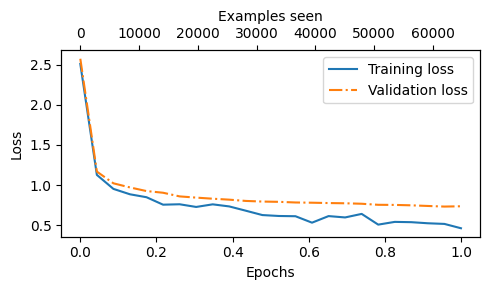

In [26]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen,
                train_values, val_values, label="loss"):
  fig, ax1 = plt.subplots(figsize=(5, 3))
  ax1.plot(epochs_seen, train_values, label=f"Training {label}")
  ax1.plot(epochs_seen, val_values, linestyle="-.",label=f"Validation {label}")
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel(label.capitalize())
  ax1.legend()

  ax2 = ax1.twiny()
  ax2.plot(examples_seen, train_values, alpha=0)
  ax2.set_xlabel("Examples seen")
  fig.tight_layout()
  plt.show()


epochs_tensor = torch.linspace(0, epochs, len(train_loss))
examples_seen_tensor = torch.linspace(0, tokens_seen[-1], len(train_loss))
plot_values(epochs_tensor, examples_seen_tensor, train_loss, val_loss)

Comparing outputs to actual answers

In [27]:
for entry in test_data[:3]:
  input_text = format_input(entry)
  token_ids = generate(model=gpt, input=text2token(input_text, tokenizer).to(device),max_new_tokens=64,
                      context_window=NEW_CONFIG["context_window"], temperature=1.5, top_k = 20, eos_id=50256)
  generated_text = token2text(token_ids, tokenizer)

  response_text = (generated_text[len(input_text):].replace("### Response:", "").strip())
  print(input_text)
  print(f"\nCorrect response:\n>> {entry['output']}")
  print(f"\nModel response:\n>> {response_text.strip()}")
  print("---------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Explain the primary function of the human heart.

Correct response:
>> The primary function of the human heart is to pump blood throughout the body, delivering oxygen and nutrients to tissues and removing carbon dioxide and other wastes.

Model response:
>> The primary function of the human heart is to pump blood directly into the tissues and to release glucose in blood after blood is pumped into its surrounding tissues.
---------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Reword the following sentence to the future tense.

### Input:
He is reading a novel inspired by his grandmother.

Correct response:
>> He will be reading a novel inspired by his grandmother.

Model response:
>> ### Input:
He is reading a novel inspired by his grandmother. Read the excerpt of the s